In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('ecommerce.csv')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,554697,21166,COOK WITH WINE METAL SIGN,1,5/25/2011 17:31,2.08,14584,United Kingdom
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,7/24/2011 11:58,2.55,17114,United Kingdom
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,7/19/2011 12:54,1.65,15311,United Kingdom
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,7/13/2011 11:34,1.25,16843,United Kingdom
4,544450,21789,KIDS RAIN MAC PINK,3,2/20/2011 12:23,0.85,17811,United Kingdom


Anda bekerja sebagai seorang data scientist, atasan anda mengirimkan anda data kepada anda dan meminta untuk memberikan analisa dengan menggunakan :
- Semua metode pada proses Exploratory Data Analysis. Lakukan proses Feature Engineering terlebih dahulu dan mengecek secara teliti pada tiap kolom data sembari melakukan data understanding.
- Buat 5 pertanyaan analisa
- Jawab dengan pendekatan metode data manipulation (sorting, filtering, group by, pivot, melt, crosstab, working with datetime, dsb sesuaikan dengan keperluan anda terkait dengan pertanyaan analisa yang anda siapkan)
- Buatlah visualisasi grafik supaya mempermudah dalam ekstraksi insight setelah menjawab menggunakan metode data manipulation diatas
- Tulis insight anda dari hasil visualisasi yang anda lakukan sebagai bentuk jawaban dari pertanyaan analisis yang anda ajukan

**Data Understanding**

In [ ]:
print(f"Jumlah baris dan kolom dataset : {df.shape}")

Jumlah baris dan kolom dataset : (4870, 8)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   object 
 2   Description  4870 non-null   object 
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   object 
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 304.5+ KB


InvoiceDate masih bertipe object sehingga perlu dikonversi menjadi datetime

In [ ]:
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID
count,4870.000000,4870.000000,4870.000000,4870.000000
mean,560586.577413,12.945791,2.937057,15291.004312
std,13211.347819,38.145988,4.744515,1709.035002
min,536365.000000,1.000000,0.040000,12347.000000
25%,548861.000000,2.000000,1.250000,13975.000000
50%,561895.000000,5.000000,1.950000,15144.000000
75%,572126.000000,12.000000,3.750000,16793.250000
max,581585.000000,992.000000,145.000000,18283.000000


In [ ]:
df.describe(include='object')

,StockCode,Description,InvoiceDate,Country
count,4870,4870,4870,4870
unique,1773,1807,3757,31
top,85099B,JUMBO BAG RED RETROSPOT,8/2/2011 10:34,United Kingdom
freq,24,24,8,4346


**Feature Engineering**

Tujuan
Mengubah kolom InvoiceDate menjadi tipe datetime agar dapat dianalisis berdasarkan waktu

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4870 non-null   int64         
 1   StockCode    4870 non-null   object        
 2   Description  4870 non-null   object        
 3   Quantity     4870 non-null   int64         
 4   InvoiceDate  4870 non-null   datetime64[ns]
 5   UnitPrice    4870 non-null   float64       
 6   CustomerID   4870 non-null   int64         
 7   Country      4870 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 304.5+ KB


**Cek Missing Value**

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


Tidak ditemukan missing value, tidak perlu dilakukan penanganan data kosong

**Cek Duplicate**

In [ ]:
df.duplicated().sum()

np.int64(0)

Tidak ditemukan data duplicate, sehingga tidak perlu dilakukan penanganan data duplicate.

In [ ]:
df.nunique()

,0
InvoiceNo,3804
StockCode,1773
Description,1807
Quantity,68
InvoiceDate,3757
UnitPrice,118
CustomerID,1932
Country,31




*   Dataset terdiri dari 3.804 invoice unik
*   Dataset memiliki 1.773 produk unik (StockCode) dan 1.807 deskripsi produk
*  Terdapat 1932 pelanggan unik dan transaksi berasal dari 31 negara.





In [ ]:
df['Country'].value_counts()

,count
Country,
United Kingdom,4346
Germany,121
EIRE,90
France,89
Switzerland,28
Netherlands,26
Spain,25
Belgium,21
Portugal,16


In [ ]:
df['StockCode'].value_counts().head(10)

,count
StockCode,
85099B,24
47566,22
22423,21
85123A,19
22197,18
84991,18
22993,16
23203,16
22720,16


In [ ]:
df['Description'].value_counts().head(10)

,count
Description,
JUMBO BAG RED RETROSPOT,24
PARTY BUNTING,22
REGENCY CAKESTAND 3 TIER,21
WHITE HANGING HEART T-LIGHT HOLDER,19
60 TEATIME FAIRY CAKE CASES,18
SET OF 3 CAKE TINS PANTRY DESIGN,16
SET OF 4 PANTRY JELLY MOULDS,16
ASSORTED COLOUR BIRD ORNAMENT,15
JAM MAKING SET PRINTED,15


**Exploratory Data Analysis**

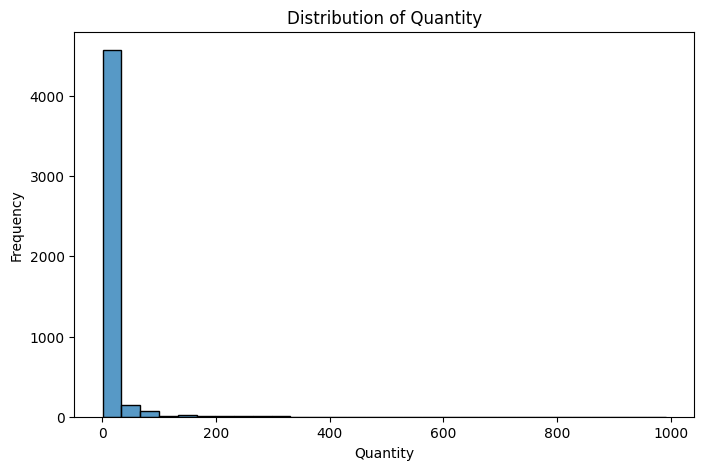

In [ ]:
#Distribusi Quantity

plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=30)

plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

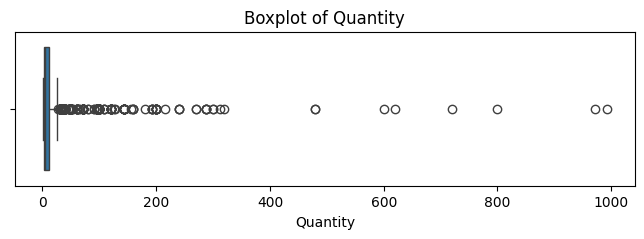

In [ ]:
#Boxplot Quantity

plt.figure(figsize=(8,2))
sns.boxplot(x=df['Quantity'])

plt.title('Boxplot of Quantity')

plt.show()

In [ ]:
df['Quantity'].describe()

,Quantity
count,4870.000000
mean,12.945791
std,38.145988
min,1.000000
25%,2.000000
50%,5.000000
75%,12.000000
max,992.000000


In [ ]:
df['Quantity'].median()

5.0

Berdasarkan histogram dan boxplot, distribusi quantity menunjukkan pola right skewed, dimana sebagian besar transaksi memiliki pembelian yang relatif kecil.

Median quantity adalah 5, sedangkan 75% transaksi memiliki Quantity <= 12. Namun terdapat beberapa pembelian yang sangat tinggi (outlier) yang terlihat pada boxplot

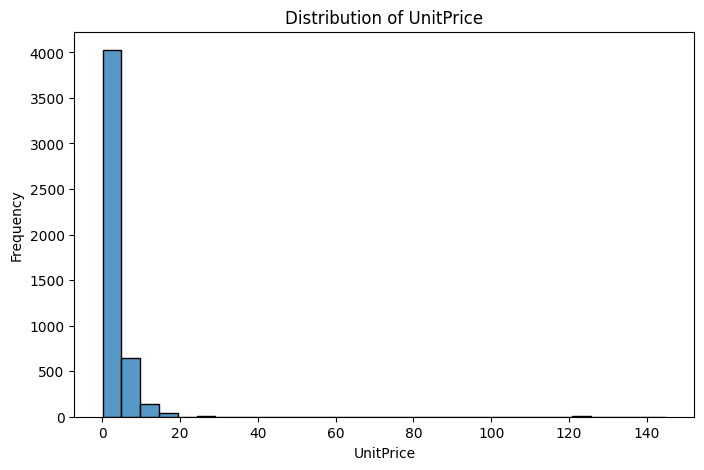

In [ ]:
#Distribution of UnitPrice

plt.figure(figsize=(8,5))
sns.histplot(df['UnitPrice'], bins=30)

plt.title('Distribution of UnitPrice')
plt.xlabel('UnitPrice')
plt.ylabel('Frequency')
plt.show()

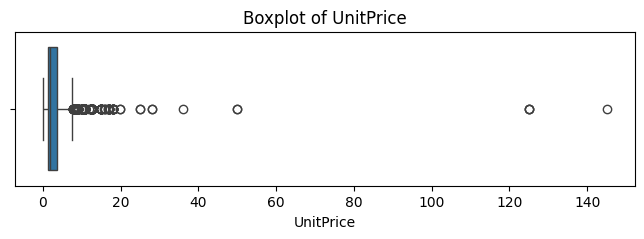

In [ ]:
#Boxplot UnitPrice

plt.figure(figsize=(8,2))
sns.boxplot(x=df['UnitPrice'])

plt.title('Boxplot of UnitPrice')

plt.show()

In [ ]:
df['UnitPrice'].describe()

,UnitPrice
count,4870.000000
mean,2.937057
std,4.744515
min,0.040000
25%,1.250000
50%,1.950000
75%,3.750000
max,145.000000


Berdasarkan histogram dan boxplot, distribusi UnitPrice menunjukkan pola right-skewed, dimana sebagian besar produk memiliki harga yang relatif rendah.

Median unitprice adalah 1.95, sedangkan 75% produk memiliki harga <= 3.75. Selain itu, terdapat beberapa outlier yang memiliki harga jauh lebih tinggi.

Pertanyaan Analisa



1.   Negara mana yang menghasilkan nilai transaksi/revenue terbesar?
2.   Produk mana yang paling banyak terjual berdasarkan total quantity?
3. Bagaimana tren revenue per bulan?
4. Customer paling banyak berasal dari negara mana?
5. Hari apa yang memiliki transaksi terbanyak?

In [ ]:
#Feature Engineering - Membuat kolom revenue

df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,2.08
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,5.10
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,1.65
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,15.00
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,2.55


Kolom revenue merupakan hasil perkalian antara quantity dan unit price. Revenue digunakan untuk menghitung nilai transaksi

In [ ]:
#Question 1 Negara mana yang menghasilkan total revenue terbesar?

country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

country_revenue

,Revenue
Country,
United Kingdom,93011.36
Netherlands,3622.33
Germany,3363.77
EIRE,3156.78
France,2320.55
Sweden,988.74
Australia,937.00
Switzerland,902.52
Portugal,562.90


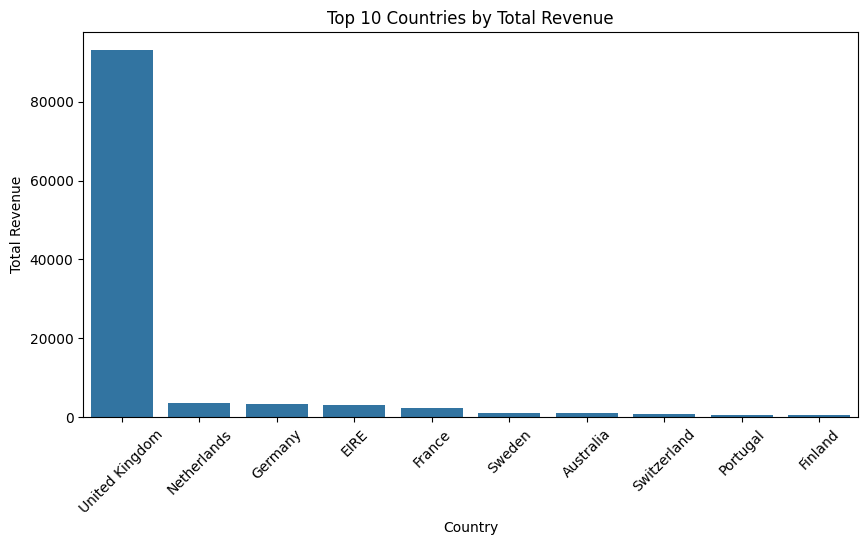

In [ ]:
#Top 10 negara dengan total revenue terbesar

top10_country = country_revenue.head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top10_country.index, y=top10_country.values)

plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

Insight Question 1

Berdasarkan hasil analisis, United Kingdom adalah negara dengan total revenue terbesar, yaitu 93,011.36, jauh lebih tinggi dibandingkan negara lainnya. Hal ini menunjukkan bahwa market utama berada di UK, dan menjadi kontributor terbesar terhadap pendapatan perusahaan

In [ ]:
#Questions 2 Produk mana yang paling banyak terjual berdasarkan total quantity?

product_quantity = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

product_quantity

,Quantity
Description,
WHITE HANGING HEART T-LIGHT HOLDER,1291
CREAM HEART CARD HOLDER,1032
"WRAP, BILLBOARD FONTS DESIGN",825
JUMBO BAG RED RETROSPOT,783
MIRROR MOSAIC T-LIGHT HOLDER,720
...,...
WOOD STAMP SET BEST WISHES,1
WOODEN REGATTA BUNTING,1
WOODEN SKITTLES GARDEN SET,1


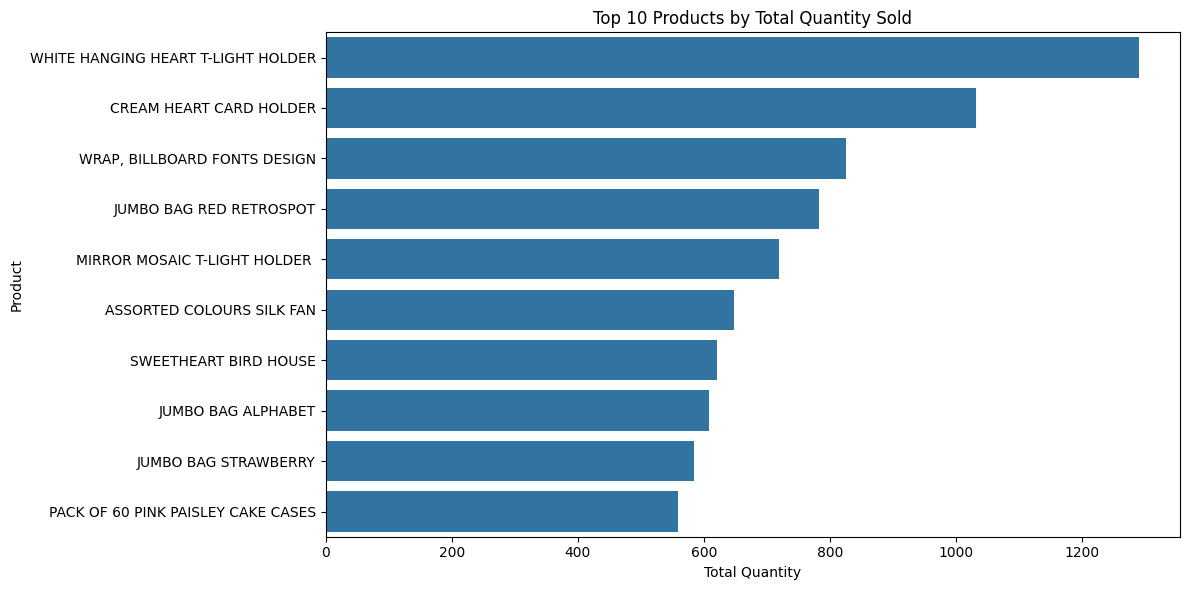

In [ ]:
#Top 10 produk berdasarkan total quantity
top10_product = product_quantity.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top10_product.values,
    y=top10_product.index
)

plt.title('Top 10 Products by Total Quantity Sold')
plt.xlabel('Total Quantity')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

Berdasarkan hasil analisis, White Hanging Heart T-Light Holder adalah produk yang terjual paling banyak, yaitu 1.291 unit. Hal ini menunjukkan bahwa produk tersebut memiliki permintaan yang tinggi dibandingkan produk lainnya.

3. Bagaimana tren revenue per bulan?

In [ ]:
#kolom yearmonth

df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

df[['InvoiceDate', 'YearMonth']].head()

,InvoiceDate,YearMonth
0,2011-05-25 17:31:00,2011-05
1,2011-07-24 11:58:00,2011-07
2,2011-07-19 12:54:00,2011-07
3,2011-07-13 11:34:00,2011-07
4,2011-02-20 12:23:00,2011-02


In [ ]:
monthly_revenue = (
    df.groupby('YearMonth')['Revenue']
    .sum()
)

monthly_revenue

,Revenue
YearMonth,
2010-12,10810.55
2011-01,6247.52
2011-02,6152.46
2011-03,7162.64
2011-04,6357.63
2011-05,6987.24
2011-06,7203.93
2011-07,7569.27
2011-08,9904.91


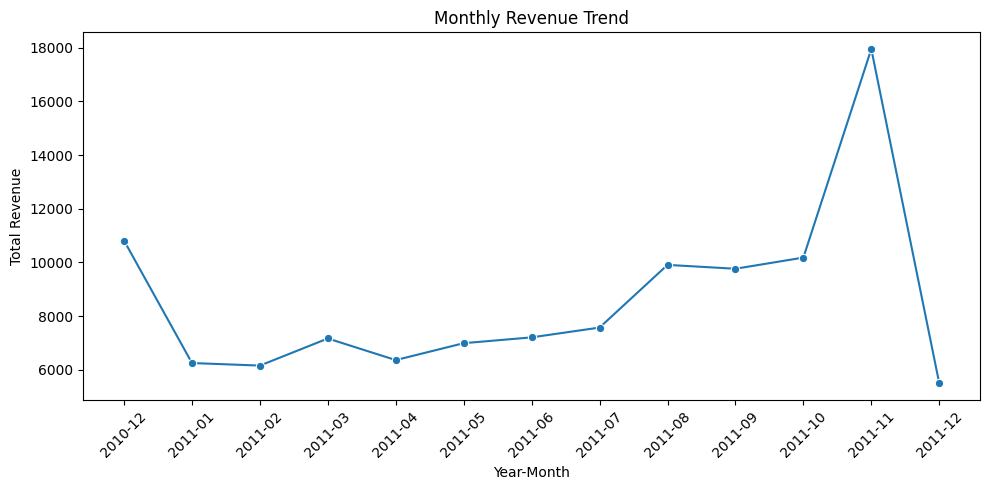

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(
    x=monthly_revenue.index.astype(str),
    y=monthly_revenue.values,
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Insight

Berdasarkan hasil analisis, revenue relatif stabil pada periode Januari 2011 hingga Juli 2011. Revenue kemudian meningkat mulai Agustus hingga mencapai puncaknya pada bulan November 2011 sebesar 17.948,84, kemudian menurun di Desember 2011.

In [ ]:
#Question 4 Customer paling banyak berasal dari negara mana?

customer_country = (
    df.groupby('Country')['CustomerID']
    .nunique()
    .sort_values(ascending=False)
)

customer_country

,CustomerID
Country,
United Kingdom,1735
Germany,49
France,43
Spain,12
Switzerland,12
Belgium,11
Portugal,8
Finland,5
Sweden,5


In [ ]:
top10_customer = customer_country.head(10)

top10_customer

,CustomerID
Country,
United Kingdom,1735
Germany,49
France,43
Spain,12
Switzerland,12
Belgium,11
Portugal,8
Finland,5
Sweden,5


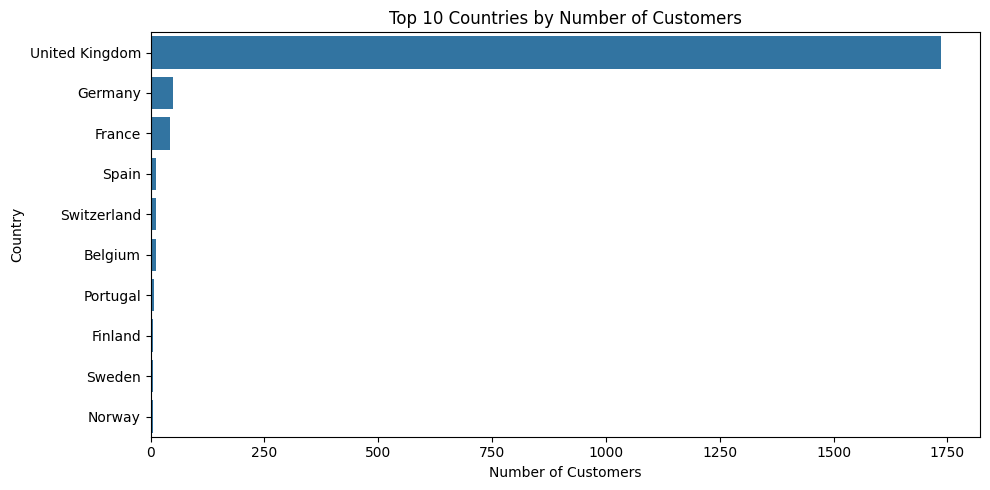

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=top10_customer.values,
    y=top10_customer.index
)

plt.title('Top 10 Countries by Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

**Insight**

Berdasarkan hasil analisis, United Kingdom memiliki jumlah customer terbanyak, yaitu 1.735 customer, jauh lebih tinggi dibandingkan negara lainnya. Hal ini menunjukkan bahwa sebagian besar customer berasal dari UK dan menjadi market utama perusahaan.

Temuan ini juga sejalan dengan hasil analisis sebelumnya, yaitu UK adalah negara dengan total revenue tertinggi

**5. Hari apa yang memiliki transaksi terbanyak?**

In [ ]:
#Questions 5 Hari apa yang memiliki transaksi terbanyak?

df['Day'] = df['InvoiceDate'].dt.day_name()

df[['InvoiceDate', 'Day']].head()

,InvoiceDate,Day
0,2011-05-25 17:31:00,Wednesday
1,2011-07-24 11:58:00,Sunday
2,2011-07-19 12:54:00,Tuesday
3,2011-07-13 11:34:00,Wednesday
4,2011-02-20 12:23:00,Sunday


In [ ]:
day_transaction = (
    df.groupby('Day')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
)

day_transaction

,InvoiceNo
Day,
Thursday,783
Wednesday,679
Tuesday,647
Monday,602
Sunday,560
Friday,533


In [ ]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]

day_transaction = day_transaction.reindex(day_order)

day_transaction

,InvoiceNo
Day,
Monday,602.0
Tuesday,647.0
Wednesday,679.0
Thursday,783.0
Friday,533.0
Saturday,NaN
Sunday,560.0


In [ ]:
day_transaction = (
    day_transaction
    .reindex(day_order)
    .fillna(0)
)

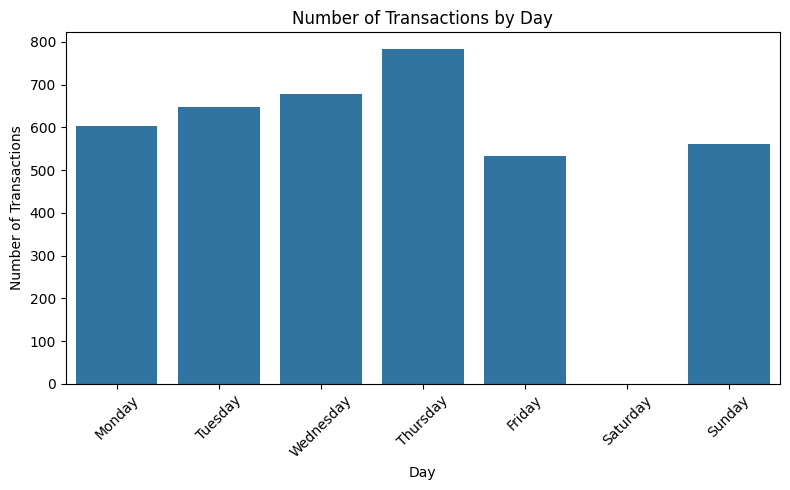

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=day_transaction.index,
    y=day_transaction.values
)

plt.title('Number of Transactions by Day')
plt.xlabel('Day')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insight**

Berdasarkan hasil analisis, transaksi paling banyak terjadi pada hari kamis (Thursday) dengan total 783 transaksi. Sementara itu pada hari Sabtu (Saturday) tidak ada transaksi.

**Additional Data Manipulation**

In [ ]:
#Filtering

#Transaksi dengan pembelian dalam jumlah besar?
#Filter transakksi dengan quantity >=20

bulk_order = df[df['Quantity'] >= 20]
bulk_order.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth,Day
17,569640,23197,SKETCHBOOK MAGNETIC SHOPPING LIST,36,2011-10-05 12:25:00,1.45,12471,Germany,52.20,2011-10,Wednesday
21,543631,21500,PINK POLKADOT WRAP,25,2011-02-10 16:17:00,0.42,14081,United Kingdom,10.50,2011-02,Thursday
29,561875,23311,VINTAGE CHRISTMAS STOCKING,24,2011-07-31 12:05:00,2.55,14885,United Kingdom,61.20,2011-07,Sunday
34,568062,85015,SET OF 12 VINTAGE POSTCARD SET,24,2011-09-23 13:18:00,0.65,14014,United Kingdom,15.60,2011-09,Friday
36,543354,21916,SET 12 RETRO WHITE CHALK STICKS,24,2011-02-07 13:50:00,0.42,13458,United Kingdom,10.08,2011-02,Monday


In [ ]:
bulk_order['Description'].value_counts().head(10)

,count
Description,
60 TEATIME FAIRY CAKE CASES,10
JUMBO BAG RED RETROSPOT,8
WHITE HANGING HEART T-LIGHT HOLDER,6
TRAVEL CARD WALLET KEEP CALM,6
MINI PAINT SET VINTAGE,5
JUMBO BAG ALPHABET,5
POPCORN HOLDER,5
WOODEN HEART CHRISTMAS SCANDINAVIAN,5
PARTY BUNTING,4


Berdasarkan hasil filtering, transaksi dengan pembelian besar (quantity >= 20) didominasi oleh beberapa produk tertentu.

Produk yang mendominasi adalah


*   60 TEATIME FAIRY CAKE CASES
*   JUMBO BAG RED RETROSPOT
*   WHITE HANGING HEART T-LIGHT HOLDER
*   TRAVEL CARD WALLET KEEP CALM

In [ ]:
#Pivot Table
#Bagaimana perbandingan revenue bulanan pada tiga negara dengan revenue terbesar?

top3_country = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

top3_country

Index(['United Kingdom', 'Netherlands', 'Germany'], dtype='object', name='Country')

In [ ]:
pivot_revenue = pd.pivot_table(
    df[df['Country'].isin(top3_country)],
    values='Revenue',
    index='YearMonth',
    columns='Country',
    aggfunc='sum',
    fill_value=0
)

pivot_revenue

Country,Germany,Netherlands,United Kingdom
YearMonth,,,
2010-12,200.46,0.00,9924.99
2011-01,209.50,208.32,4772.16
2011-02,213.15,360.00,4712.69
2011-03,431.82,105.00,5134.13
2011-04,356.75,90.00,5589.68
2011-05,171.45,365.60,6080.95
2011-06,290.92,855.75,4993.20
2011-07,171.22,0.00,5721.22
2011-08,237.89,697.00,8277.62


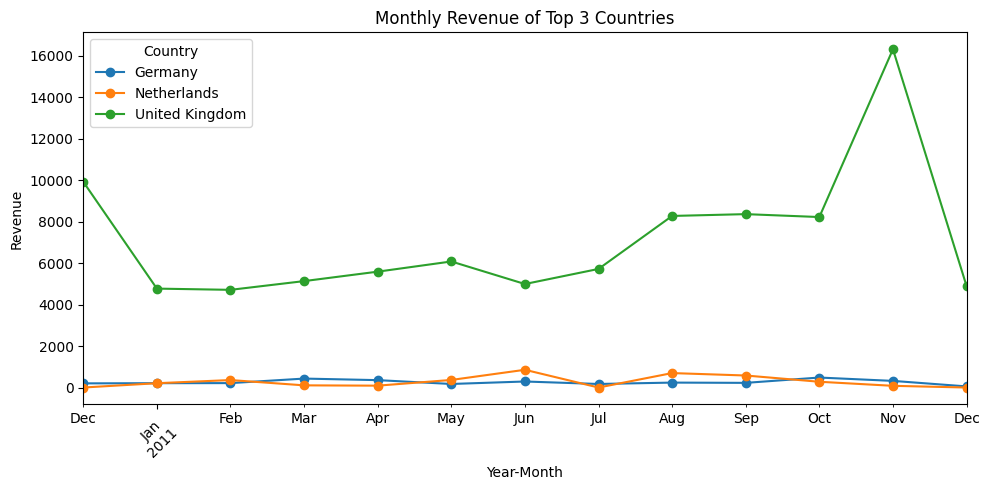

In [ ]:
pivot_revenue.plot(figsize=(10,5), marker='o')

plt.title('Monthly Revenue of Top 3 Countries')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Berdasarkan hasil analisis dan visualisasi, United Kingdom memiliki revenue yang jauh lebih tinggi dibandingkan Germany dan Netherlands. Revenue UK mencapai puncaknya pada November 2011.

In [ ]:
#Multivariate Analysis
##Correlation Heatmap

#Memilih kolom numerik
numeric_df = df.select_dtypes(include='number')

numeric_df.head()

,InvoiceNo,Quantity,UnitPrice,CustomerID,Revenue
0,554697,1,2.08,14584,2.08
1,561038,2,2.55,17114,5.10
2,560552,1,1.65,15311,1.65
3,559884,12,1.25,16843,15.00
4,544450,3,0.85,17811,2.55


In [ ]:
correlation_matrix = numeric_df.corr()

correlation_matrix

,InvoiceNo,Quantity,UnitPrice,CustomerID,Revenue
InvoiceNo,1.000000,-0.028187,-0.061637,0.027120,-0.021428
Quantity,-0.028187,1.000000,-0.083283,-0.008040,0.788586
UnitPrice,-0.061637,-0.083283,1.000000,-0.035106,0.091612
CustomerID,0.027120,-0.008040,-0.035106,1.000000,-0.005556
Revenue,-0.021428,0.788586,0.091612,-0.005556,1.000000


In [ ]:
numeric_df = df[['Quantity','UnitPrice','Revenue']]

correlation_matrix = numeric_df.corr()

numeric_df.head()

,Quantity,UnitPrice,Revenue
0,1,2.08,2.08
1,2,2.55,5.10
2,1,1.65,1.65
3,12,1.25,15.00
4,3,0.85,2.55


In [ ]:
#Menghitung korelasi antar kolom numerik
correlation_matrix = numeric_df.corr()

correlation_matrix

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.083283,0.788586
UnitPrice,-0.083283,1.000000,0.091612
Revenue,0.788586,0.091612,1.000000


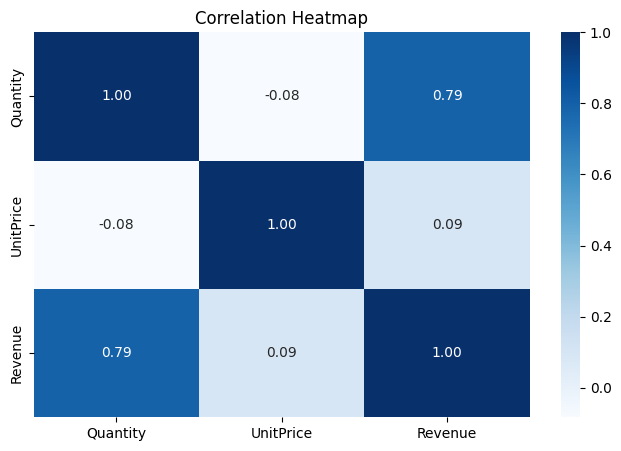

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

**Insight**

Berdasarkan hasil analisis, quantity memiliki korelasi positif yang kuat terhadap revenue (0,79). Hal ini menunjukkan bahwa semakin banyak produk yang terjual, maka  semakin tinggi revenue yang dihasilkan.

Sementara itu, unitprice memiliki korelasi yang sangat lemah terhadap revenue (0,09). Hal ini menunjukkan bahwa perubahan harga satuan produk tidak terlalu berpengaruh terhadap revenue.

Conclusion



*   United Kingdom merupakan market utama perusahaan dengan revenue dan jumlah customer tertinggi
*   Produk white hanging heart T-light Holder menjadi produk yang terjual paling banyak.
*   Revenue menunjukkan peningkatan hingga November 2011, dan aktivitas transaksi paling tinggi terjadi pada hari Kamis.
*   Hasil korelasi menunjukkan bahwa revenue lebih dipengaruhi oleh jumlah produk yang terjual.


